# BÁO CÁO BÀI TẬP LỚN: HỒI QUY LOGISTIC (LOGISTIC REGRESSION)
## BÀI TOÁN PHÂN LOẠI QUẢ CHÍN / CHƯA CHÍN (0, 1) TRÊN TẬP DỮ LIỆU 1000 QUẢ
### SO SÁNH 3 HÀM LOSS FUNCTION BẰNG THUẬT TOÁN STOCHASTIC GRADIENT DESCENT (SGD)

---
### 👥 THÔNG TIN NHÓM VÀ PHÂN CÔNG NHIỆM VỤ

| STT | Họ và Tên | Mã số sinh viên | Vai trò & Nhiệm vụ thực hiện | Tỷ lệ đóng góp (%) |
|:---:|:---|:---:|:---|:---:|
| 1 | [Họ tên sinh viên 1] | [MSSV 1] | Trưởng nhóm: Thiết kế thuật toán SGD, viết báo cáo cơ sở lý thuyết toán học | 34% |
| 2 | [Họ tên sinh viên 2] | [MSSV 2] | Xây dựng dataset 1000 quả, chuẩn hóa Z-score, lập trình 3 hàm Loss & Gradient | 33% |
| 3 | [Họ tên sinh viên 3] | [MSSV 3] | Huấn luyện mô hình, vẽ biểu đồ so sánh Loss & Decision Boundary, phân tích kết quả | 33% |

*Lưu ý: Các thành viên điền họ tên, MSSV và điều chỉnh tỷ lệ % đóng góp thực tế của nhóm mình.*


---
# PHẦN 1: MÔ TẢ BÀI TOÁN VÀ CƠ SỞ LÝ THUYẾT

## 1.1. Mô tả bài toán phân loại quả chín / chưa chín (0, 1)
* **Tên bài toán:** Phân loại nhị phân (*Binary Classification*) độ chín của trái cây:
  * **Lớp chín (Class 1):** Quả chín (Ripe) - Quy ước nhãn $1$ (hoặc $+1$).
  * **Lớp chưa chín (Class 0):** Quả xanh / chưa chín (Unripe) - Quy ước nhãn $0$ (hoặc $-1$).
* **Số lượng điểm dữ liệu (Datapoints):** **1000 quả** (500 quả chưa chín và 500 quả chín).
* **Các đặc trưng đầu vào (Features):**
  1. $x_1$: **Khối lượng (Weight)** - đơn vị gram (g). Quả chín thường có kích thước phát triển đầy đủ và trọng lượng lớn hơn.
  2. $x_2$: **Chỉ số màu sắc (Color Code / Color Index)** - Thang đo từ 0 (xanh lục), 1 (vàng nhạt), đến 2 (vàng cam chín).
* **Mô hình Hồi quy Logistic (Logistic Regression):**
  * Hàm tổ hợp tuyến tính (Logit):
    $$z = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + b$$
  * Hàm kích hoạt Sigmoid chuyển đổi $z$ về khoảng xác suất $(0, 1)$:
    $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
  * Đạo hàm của hàm Sigmoid có tính chất rất quan trọng:
    $$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

---
## 1.2. Trình bày chi tiết toán học của 3 hàm Loss & Đạo hàm Gradient

### 1️⃣ Hàm 1: Sigmoid Activation với nhãn $y \in \{-1, +1\}$ (Logistic Loss)
* **Quy ước nhãn:** $y_i \in \{-1, +1\}$.
* **Ý nghĩa xác suất:** Xác suất dự đoán mẫu thuộc về lớp $+1$ là $P(y_i = +1 | \mathbf{x}_i) = \sigma(z_i)$. Do tính đối xứng $\sigma(-z) = 1 - \sigma(z)$, ta có công thức xác suất tổng quát cho cả hai lớp:
  $$P(y_i | \mathbf{x}_i) = \sigma(y_i z_i) = \frac{1}{1 + e^{-y_i z_i}}$$
* **Hàm mất mát cho một mẫu (Negative Log-Likelihood):**
  $$\mathcal{L}_{\text{logistic}}(y_i, z_i) = -\ln P(y_i | \mathbf{x}_i) = \ln(1 + e^{-y_i z_i})$$
* **Đạo hàm Gradient (dùng cập nhật trọng số trong SGD):**
  $$\frac{\partial \mathcal{L}}{\partial z_i} = \frac{-y_i e^{-y_i z_i}}{1 + e^{-y_i z_i}} = \frac{-y_i}{1 + e^{y_i z_i}} = -y_i (1 - \sigma(y_i z_i))$$
  Áp dụng quy tắc chuỗi theo $\mathbf{w}$ và $b$:
  $$\nabla_{\mathbf{w}} \mathcal{L} = \frac{-y_i \mathbf{x}_i}{1 + e^{y_i z_i}}, \quad \nabla_{b} \mathcal{L} = \frac{-y_i}{1 + e^{y_i z_i}}$$

---
### 2️⃣ Hàm 2: Binary Cross-Entropy (BCE) với nhãn $y \in \{0, 1\}$
* **Quy ước nhãn:** $y_i \in \{0, 1\}$.
* **Xác suất dự đoán:** $p_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$.
* **Hàm mất mát cho một mẫu:**
  $$\mathcal{L}_{\text{BCE}}(y_i, p_i) = - \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right]$$
* **Đạo hàm Gradient:**
  $$\frac{\partial \mathcal{L}}{\partial p_i} = -\frac{y_i}{p_i} + \frac{1 - y_i}{1 - p_i} = \frac{p_i - y_i}{p_i(1 - p_i)}$$
  $$\frac{\partial p_i}{\partial z_i} = p_i (1 - p_i) = \sigma'(z_i)$$
  Nhân lại theo quy tắc chuỗi, thành phần $p_i(1 - p_i)$ ở mẫu số triệt tiêu hoàn toàn với đạo hàm Sigmoid:
  $$\frac{\partial \mathcal{L}}{\partial z_i} = \frac{p_i - y_i}{p_i(1 - p_i)} \cdot p_i (1 - p_i) = p_i - y_i$$
  $$\nabla_{\mathbf{w}} \mathcal{L} = (p_i - y_i) \mathbf{x}_i, \quad \nabla_{b} \mathcal{L} = p_i - y_i$$

---
### 3️⃣ Hàm 3: Mean Squared Error (MSE) kết hợp Sigmoid với nhãn $y \in \{0, 1\}$
* **Quy ước nhãn:** $y_i \in \{0, 1\}$.
* **Xác suất dự đoán:** $p_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$.
* **Hàm mất mát cho một mẫu:**
  $$\mathcal{L}_{\text{MSE}}(y_i, p_i) = (y_i - p_i)^2$$
* **Đạo hàm Gradient:**
  $$\frac{\partial \mathcal{L}}{\partial p_i} = -2 (y_i - p_i)$$
  $$\frac{\partial p_i}{\partial z_i} = p_i (1 - p_i)$$
  Nhân lại theo quy tắc chuỗi:
  $$\frac{\partial \mathcal{L}}{\partial z_i} = -2 (y_i - p_i) \cdot p_i (1 - p_i)$$
  $$\nabla_{\mathbf{w}} \mathcal{L} = -2 (y_i - p_i) p_i (1 - p_i) \mathbf{x}_i, \quad \nabla_{b} \mathcal{L} = -2 (y_i - p_i) p_i (1 - p_i)$$

---
## 1.3. Bảng so sánh bản chất lý thuyết giữa 3 hàm Loss

| Tiêu chí | 1. Logistic Loss (y ∈ {-1, 1}) | 2. Binary Cross-Entropy (y ∈ {0, 1}) | 3. MSE + Sigmoid (y ∈ {0, 1}) |
|:---|:---|:---|:---|
| **Dạng toán học của hàm số** | **Hàm lồi (Convex)** toàn cục | **Hàm lồi (Convex)** toàn cục | **Hàm phi lồi (Non-convex)** |
| **Khả năng hội tụ** | Đảm bảo hội tụ tới nghiệm tối ưu toàn cục | Đảm bảo hội tụ tới nghiệm tối ưu toàn cục | Dễ bị kẹt ở cực tiểu cục bộ (*Local minima*) |
| **Vấn đề triệt tiêu Gradient** | ❌ Không bị triệt tiêu khi sai số lớn | ❌ Gradient tỉ lệ trực tiếp với sai số $(p_i - y_i)$ | ⚠️ **Bị triệt tiêu gradient** do có thừa số $p_i(1 - p_i)$ |
| **Tốc độ học khi dự đoán rất sai** | Học rất nhanh do lực đẩy gradient lớn | Học rất nhanh do lực đẩy gradient lớn | Bị chậm lại nghiêm trọng do $p_i(1-p_i) \to 0$ |


In [1]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập hiển thị đẹp mắt cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

# Đặt seed cố định để kết quả có thể tái lập được (reproducible)
np.random.seed(42)
print("Đã nạp thành công các thư viện: NumPy, Pandas, Matplotlib!")


Đã nạp thành công các thư viện: NumPy, Pandas, Matplotlib!


---
# PHẦN 2: TẠO DỮ LIỆU CỦA NHÓM (DATASET 1000 QUẢ) VÀ TIỀN XỬ LÝ

Nhóm xây dựng bộ dữ liệu dựa trên bài toán phân loại trái cây:
* **Quy mô tập dữ liệu (Datapoints):** **1000 quả**, gồm:
  * **500 quả Chưa chín (Class 0):** Cân nặng trung bình ~155g, màu xanh lục (0.0 - 0.7).
  * **500 quả Đã chín (Class 1):** Cân nặng trung bình ~205g, màu vàng cam chín (1.2 - 2.0).
* **2 đặc trưng:**
  1. `Weight` (Khối lượng): dao động tự nhiên từ khoảng 90g đến 280g.
  2. `ColorCode` (Mã màu sắc): từ 0.0 (xanh) đến 2.0 (vàng cam chín).


In [2]:
# 1. Khởi tạo số lượng mẫu: 1000 quả (500 quả mỗi lớp)
n_samples_each = 500

# Sinh 500 mẫu lớp Chưa chín (Unripe - Class 0 / Nhãn -1):
weights_unripe = np.random.normal(loc=155, scale=28, size=n_samples_each)
colors_unripe = np.random.normal(loc=0.45, scale=0.35, size=n_samples_each)
colors_unripe = np.clip(colors_unripe, 0.0, 2.0)
y_unripe_pm1 = -np.ones(n_samples_each)

# Sinh 500 mẫu lớp Đã chín (Ripe - Class 1 / Nhãn +1):
weights_ripe = np.random.normal(loc=205, scale=28, size=n_samples_each)
colors_ripe = np.random.normal(loc=1.55, scale=0.35, size=n_samples_each)
colors_ripe = np.clip(colors_ripe, 0.0, 2.0)
y_ripe_pm1 = np.ones(n_samples_each)

# 2. Ghép dữ liệu thành bộ Dataset 1000 quả hoàn chỉnh
X_raw = np.vstack([
    np.column_stack([weights_unripe, colors_unripe]),
    np.column_stack([weights_ripe, colors_ripe])
])
y_pm1 = np.concatenate([y_unripe_pm1, y_ripe_pm1])  # Nhãn {-1, +1} cho Logistic Loss
y_01 = np.where(y_pm1 == -1, 0, 1)                  # Nhãn {0, 1} cho BCE và MSE

# Cấu hình pandas để in đầy đủ các cột ra màn hình không bị cắt dấu ba chấm (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 3. Đưa vào DataFrame của Pandas với tên cột trực quan, giải thích rõ 2 hệ nhãn
df = pd.DataFrame({
    'Cân_nặng(g)': X_raw[:, 0].round(1),
    'Mã_màu(0-2)': X_raw[:, 1].round(2),
    'Trạng_thái': np.where(y_01 == 1, 'ĐÃ CHÍN', 'CHƯA CHÍN'),
    'Nhãn_Hàm1_Logistic(-1/1)': y_pm1.astype(int),
    'Nhãn_Hàm2,3_BCE_MSE(0/1)': y_01.astype(int)
})

print(f"Tổng số quả trong Dataset: {len(df)} quả")
print(f"Số lượng quả chưa chín: {np.sum(y_01 == 0)} quả")
print(f"Số lượng quả đã chín  : {np.sum(y_01 == 1)} quả")
print("\n=== 10 MẪU DỮ LIỆU ĐẦU TIÊN (SO SÁNH TRỰC DIỆN 2 HỆ NHÃN) ===")
print(df.head(10).to_string(index=True))
print("\n* Chú thích:")
print("  - Nhãn_Hàm1_Logistic(-1/1)  : -1 là Chưa chín, +1 là Đã chín (Dùng cho Hàm 1: Logistic Loss)")
print("  - Nhãn_Hàm2,3_BCE_MSE(0/1)  :  0 là Chưa chín,  1 là Đã chín (Dùng cho Hàm 2: BCE và Hàm 3: MSE)")
print("\n=== THỐNG KÊ MÔ TẢ DỮ LIỆU (1000 MẪU) ===")
print(df.describe().round(2).to_string())


Tổng số quả trong Dataset: 1000 quả
Số lượng quả chưa chín: 500 quả
Số lượng quả đã chín  : 500 quả

=== 10 MẪU DỮ LIỆU ĐẦU TIÊN (SO SÁNH TRỰC DIỆN 2 HỆ NHÃN) ===
   Cân_nặng(g)  Mã_màu(0-2) Trạng_thái  Nhãn_Hàm1_Logistic(-1/1)  Nhãn_Hàm2,3_BCE_MSE(0/1)
0        168.9         0.77  CHƯA CHÍN                        -1                         0
1        151.1         1.12  CHƯA CHÍN                        -1                         0
2        173.1         0.00  CHƯA CHÍN                        -1                         0
3        197.6         0.65  CHƯA CHÍN                        -1                         0
4        148.4         0.22  CHƯA CHÍN                        -1                         0
5        148.4         0.28  CHƯA CHÍN                        -1                         0
6        199.2         0.24  CHƯA CHÍN                        -1                         0
7        176.5         0.15  CHƯA CHÍN                        -1                         0
8        141.9    

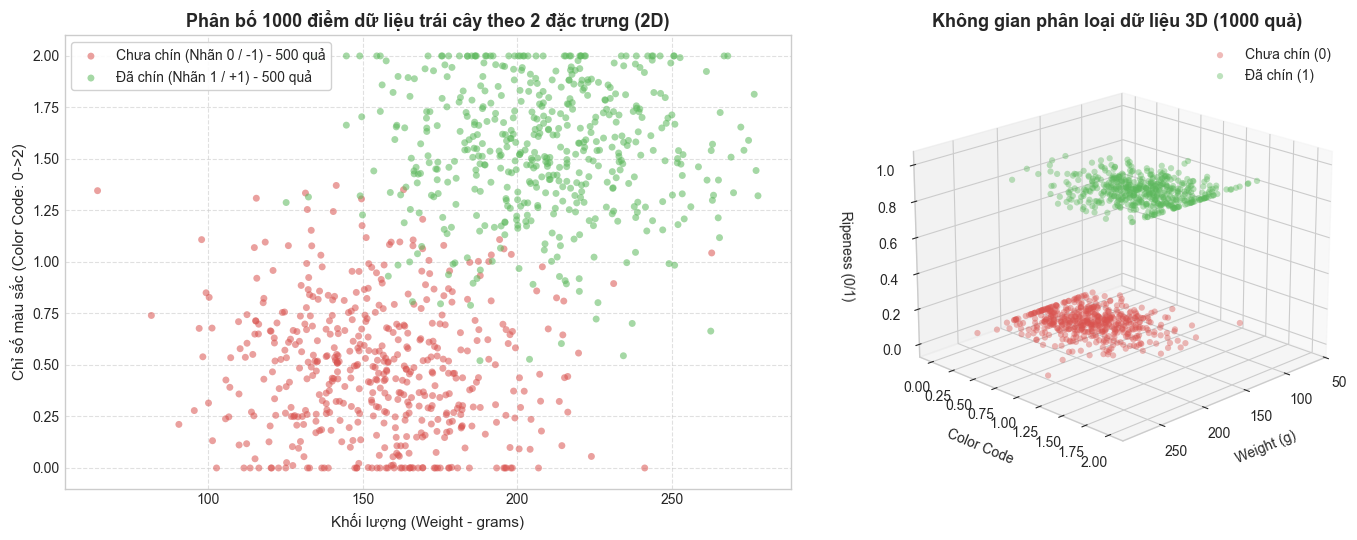

In [3]:
# Trực quan hóa dữ liệu phân bố của 1000 quả bằng biểu đồ 2D và 3D
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Biểu đồ 1: Scatter Plot 2D (Weight vs Color Code) của 1000 quả
ax1 = axes[0]
scatter_0 = ax1.scatter(X_raw[y_01 == 0, 0], X_raw[y_01 == 0, 1],
                        c='#d9534f', label='Chưa chín (Nhãn 0 / -1) - 500 quả', alpha=0.55, s=25, edgecolors='none')
scatter_1 = ax1.scatter(X_raw[y_01 == 1, 0], X_raw[y_01 == 1, 1],
                        c='#5cb85c', label='Đã chín (Nhãn 1 / +1) - 500 quả', alpha=0.55, s=25, edgecolors='none')
ax1.set_title('Phân bố 1000 điểm dữ liệu trái cây theo 2 đặc trưng (2D)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Khối lượng (Weight - grams)', fontsize=11)
ax1.set_ylabel('Chỉ số màu sắc (Color Code: 0->2)', fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Biểu đồ 3D (Weight, Color Code, Ripeness)
from mpl_toolkits.mplot3d import Axes3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
axes[1].remove() # Thay trục phụ 2D thành trục 3D

ax2.scatter(X_raw[y_01 == 0, 0], X_raw[y_01 == 0, 1], y_01[y_01 == 0],
            c='#d9534f', label='Chưa chín (0)', s=20, alpha=0.4, edgecolors='none')
ax2.scatter(X_raw[y_01 == 1, 0], X_raw[y_01 == 1, 1], y_01[y_01 == 1],
            c='#5cb85c', label='Đã chín (1)', s=20, alpha=0.4, edgecolors='none')
ax2.set_title('Không gian phân loại dữ liệu 3D (1000 quả)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Weight (g)', labelpad=8)
ax2.set_ylabel('Color Code', labelpad=8)
ax2.set_zlabel('Ripeness (0/1)', labelpad=8)
ax2.view_init(elev=20, azim=45)
ax2.legend()

plt.tight_layout()
plt.show()


### 2.2. Chuẩn hóa dữ liệu (Z-score Normalization)

> **Tại sao phải chuẩn hóa dữ liệu trước khi chạy SGD?**
> * Đặc trưng `Weight` có giá trị từ 90 đến 280g, trong khi `ColorCode` chỉ từ 0 đến 2. Sự chênh lệch thang đo này khiến bề mặt hàm mất mát bị kéo giãn thành hình elip rất hẹp, khiến thuật toán Gradient Descent bị dao động zíc-zắc và hội tụ rất chậm.
> * Chuẩn hóa Z-score đưa các đặc trưng về cùng thang đo với trung bình bằng 0 và độ lệch chuẩn bằng 1:
>   $$X_{\text{norm}} = \frac{X - \mu}{\sigma}$$


In [4]:
# Thực hiện chuẩn hóa Z-score trên toàn bộ 1000 mẫu
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)

X_norm = (X_raw - X_mean) / X_std

print("Giá trị trung bình của từng đặc trưng (mu):", X_mean.round(2))
print("Độ lệch chuẩn của từng đặc trưng (sigma):", X_std.round(2))
print("\n5 mẫu đầu tiên sau khi chuẩn hóa Z-score:\n", X_norm[:5].round(4))


Giá trị trung bình của từng đặc trưng (mu): [181.61   1.01]
Độ lệch chuẩn của từng đặc trưng (sigma): [38.39  0.62]

5 mẫu đầu tiên sau khi chuẩn hóa Z-score:
 [[-0.3309 -0.3794]
 [-0.794   0.1736]
 [-0.2208 -1.6236]
 [ 0.4175 -0.5837]
 [-0.8639 -1.2664]]


---
# PHẦN 3: LẬP TRÌNH THUẬT TOÁN STOCHASTIC GRADIENT DESCENT (SGD)

Chúng ta xây dựng các hàm toán học cốt lõi bằng NumPy từ đầu:
1. **Hàm kích hoạt Sigmoid:** `sigmoid(z) = 1 / (1 + exp(-z))` (kèm kỹ thuật clip giá trị tránh tràn số lũy thừa).
2. **3 hàm Loss và Gradient tương ứng:**
   - `logistic_loss` và `logistic_gradient` (nhãn $\pm 1$)
   - `bce_loss` và `bce_gradient` (nhãn $0/1$, xử lý an toàn epsilon $10^{-15}$ tránh $\ln(0)$)
   - `mse_loss` và `mse_gradient` (nhãn $0/1$, công thức sai số bình phương chuẩn xác)
3. **Hàm huấn luyện SGD:** Lặp qua từng epoch, xáo trộn ngẫu nhiên dữ liệu (`np.random.permutation`), cập nhật trọng số sau từng mẫu một.


In [5]:
# 1. Hàm Sigmoid
def sigmoid(z):
    # Dùng np.clip để tránh lỗi tràn số RuntimeWarning overflow trong np.exp
    z_clipped = np.clip(z, -250.0, 250.0)
    return 1.0 / (1.0 + np.exp(-z_clipped))

# ----------------------------------------------------
# 2. CÁC HÀM LOSS VÀ GRADIENT CHO TỪNG LOẠI HÀM MẤT MÁT
# ----------------------------------------------------

# === LOẠI 1: LOGISTIC LOSS (Nhãn y in {-1, +1}) ===
def logistic_loss(y, z):
    """Loss = ln(1 + exp(-y * z))"""
    # Sử dụng np.logaddexp(0, -y*z) để ổn định số học, tránh tràn số
    return float(np.logaddexp(0.0, -y * z))

def logistic_gradient(x, y, z):
    """grad_w = - (y * x) / (1 + exp(y * z)), grad_b = - y / (1 + exp(y * z))"""
    factor = - y / (1.0 + np.exp(np.clip(y * z, -250.0, 250.0)))
    grad_w = factor * x
    grad_b = float(factor)
    return grad_w, grad_b

# === LOẠI 2: BINARY CROSS-ENTROPY (Nhãn y in {0, 1}) ===
def bce_loss(y, p, eps=1e-15):
    """Loss = - [y * ln(p) + (1-y) * ln(1-p)]"""
    p_safe = np.clip(p, eps, 1.0 - eps)  # Tránh lỗi chia/log số 0
    return float(- (y * np.log(p_safe) + (1.0 - y) * np.log(1.0 - p_safe)))

def bce_gradient(x, y, p):
    """grad_w = (p - y) * x, grad_b = (p - y)"""
    diff = p - y
    grad_w = diff * x
    grad_b = float(diff)
    return grad_w, grad_b

# === LOẠI 3: MEAN SQUARED ERROR (Nhãn y in {0, 1}) ===
def mse_loss(y, p):
    """Loss = (y - p)^2"""
    return float((y - p) ** 2)

def mse_gradient(x, y, p):
    """grad_w = -2 * (y - p) * p * (1 - p) * x, grad_b = -2 * (y - p) * p * (1 - p)"""
    factor = -2.0 * (y - p) * p * (1.0 - p)
    grad_w = factor * x
    grad_b = float(factor)
    return grad_w, grad_b

print("Đã định nghĩa thành công các hàm Loss và Gradient!")


Đã định nghĩa thành công các hàm Loss và Gradient!


In [6]:
# 3. Hàm huấn luyện tổng quát bằng phương pháp Stochastic Gradient Descent (SGD)
def train_sgd(X, y, loss_type='bce', learning_rate=0.02, epochs=50, random_seed=42):
    """
    Huấn luyện mô hình Logistic Regression bằng SGD trên 1000 mẫu
    Tham số:
        X: Ma trận đặc trưng (n_samples, n_features)
        y: Vector nhãn tương ứng ({-1, 1} hoặc {0, 1})
        loss_type: 'logistic', 'bce', hoặc 'mse'
        learning_rate: Tốc độ học alpha
        epochs: Số vòng lặp qua toàn bộ dữ liệu
    """
    np.random.seed(random_seed)
    n_samples, n_features = X.shape
    
    # Khởi tạo trọng số ngẫu nhiên nhỏ và bias = 0
    w = np.random.randn(n_features) * 0.01
    b = 0.0
    
    loss_history = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        # Stochastic: Xáo trộn ngẫu nhiên thứ tự các mẫu ở mỗi epoch
        indices = np.random.permutation(n_samples)
        
        for i in indices:
            x_i = X[i]
            y_i = y[i]
            
            # Tính logit z và xác suất p
            z = float(np.dot(w, x_i) + b)
            p = float(sigmoid(z))
            
            # Tính loss và gradient tùy theo hàm loss được chọn
            if loss_type == 'logistic':
                loss_val = logistic_loss(y_i, z)
                grad_w, grad_b = logistic_gradient(x_i, y_i, z)
            elif loss_type == 'bce':
                loss_val = bce_loss(y_i, p)
                grad_w, grad_b = bce_gradient(x_i, y_i, p)
            elif loss_type == 'mse':
                loss_val = mse_loss(y_i, p)
                grad_w, grad_b = mse_gradient(x_i, y_i, p)
            else:
                raise ValueError("loss_type không hợp lệ!")
                
            epoch_loss += loss_val
            
            # CẬP NHẬT TRỌNG SỐ THEO TỪNG MẪU (Bản chất của SGD)
            w -= learning_rate * grad_w
            b -= learning_rate * grad_b
            
        avg_loss = epoch_loss / n_samples
        loss_history.append(avg_loss)
        
    return w, b, loss_history

# 4. Hàm dự đoán
def predict(X, w, b, label_type='01'):
    z = np.dot(X, w) + b
    p = sigmoid(z)
    if label_type == 'pm1':
        return np.where(p >= 0.5, 1, -1)
    else:
        return np.where(p >= 0.5, 1, 0)

# 5. Các hàm đo lường hiệu năng
def compute_metrics(y_true, y_pred, pos_label=1):
    acc = np.mean(y_true == y_pred)
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
    fn = np.sum((y_true == pos_label) & (y_pred != pos_label))
    tn = np.sum((y_true != pos_label) & (y_pred != pos_label))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    }

print("Đã xây dựng xong hàm train_sgd, predict và compute_metrics!")


Đã xây dựng xong hàm train_sgd, predict và compute_metrics!


---
# PHẦN 4: TIẾN HÀNH HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN DATASET 1000 QUẢ

Nhóm tiến hành huấn luyện 3 mô hình trên cùng điều kiện siêu tham số:
* `learning_rate` $\alpha = 0.02$
* `epochs` $= 50$ (tương đương $50 \times 1000 = 50,000$ lượt cập nhật trọng số SGD)
* Khởi tạo trọng số ngẫu nhiên cùng hạt giống (`random_seed = 42`)


In [7]:
# Thiết lập siêu tham số chung
LR = 0.02
EPOCHS = 50

print(">>> 1. ĐANG HUẤN LUYỆN MÔ HÌNH 1: LOGISTIC LOSS (Nhãn -1, +1)...")
w_log, b_log, hist_log = train_sgd(X_norm, y_pm1, loss_type='logistic', learning_rate=LR, epochs=EPOCHS)
pred_log = predict(X_norm, w_log, b_log, label_type='pm1')
metrics_log = compute_metrics(y_pm1, pred_log, pos_label=1)
print(f"   Trọng số w: {w_log.round(4)}, Bias: {b_log:.4f}")
print(f"   Loss ban đầu: {hist_log[0]:.4f} -> Loss cuối cùng: {hist_log[-1]:.4f}")
print(f"   Train Accuracy: {metrics_log['Accuracy']*100:.2f}%")

print("\n>>> 2. ĐANG HUẤN LUYỆN MÔ HÌNH 2: BINARY CROSS-ENTROPY (Nhãn 0, 1)...")
w_bce, b_bce, hist_bce = train_sgd(X_norm, y_01, loss_type='bce', learning_rate=LR, epochs=EPOCHS)
pred_bce = predict(X_norm, w_bce, b_bce, label_type='01')
metrics_bce = compute_metrics(y_01, pred_bce, pos_label=1)
print(f"   Trọng số w: {w_bce.round(4)}, Bias: {b_bce:.4f}")
print(f"   Loss ban đầu: {hist_bce[0]:.4f} -> Loss cuối cùng: {hist_bce[-1]:.4f}")
print(f"   Train Accuracy: {metrics_bce['Accuracy']*100:.2f}%")

print("\n>>> 3. ĐANG HUẤN LUYỆN MÔ HÌNH 3: MEAN SQUARED ERROR (Nhãn 0, 1)...")
w_mse, b_mse, hist_mse = train_sgd(X_norm, y_01, loss_type='mse', learning_rate=LR, epochs=EPOCHS)
pred_mse = predict(X_norm, w_mse, b_mse, label_type='01')
metrics_mse = compute_metrics(y_01, pred_mse, pos_label=1)
print(f"   Trọng số w: {w_mse.round(4)}, Bias: {b_mse:.4f}")
print(f"   Loss ban đầu: {hist_mse[0]:.4f} -> Loss cuối cùng: {hist_mse[-1]:.4f}")
print(f"   Train Accuracy: {metrics_mse['Accuracy']*100:.2f}%")

# =============================================================
# DỰ ĐOÁN TRÊN 50 QUẢ MỚI TOANH CHƯA TỪNG HUẤN LUYỆN (TEST SET)
# =============================================================
np.random.seed(2026)
n_test_each = 25
w_test_unripe = np.random.normal(155, 28, n_test_each)
c_test_unripe = np.clip(np.random.normal(0.45, 0.35, n_test_each), 0.0, 2.0)
y_test_pm1_unripe = -np.ones(n_test_each)

w_test_ripe = np.random.normal(205, 28, n_test_each)
c_test_ripe = np.clip(np.random.normal(1.55, 0.35, n_test_each), 0.0, 2.0)
y_test_pm1_ripe = np.ones(n_test_each)

X_test_raw = np.vstack([
    np.column_stack([w_test_unripe, c_test_unripe]),
    np.column_stack([w_test_ripe, c_test_ripe])
])
y_test_pm1 = np.concatenate([y_test_pm1_unripe, y_test_pm1_ripe])
perm = np.random.permutation(50)
X_test_raw = X_test_raw[perm]
y_test_pm1 = y_test_pm1[perm]
y_test_01 = np.where(y_test_pm1 == -1, 0, 1)

# Chuẩn hóa tập test theo mu và sigma của tập train
X_test_norm = (X_test_raw - X_mean) / X_std

# Đánh giá 3 mô hình trên 50 quả mới
pred_log_test = predict(X_test_norm, w_log, b_log, label_type='pm1')
pred_bce_test = predict(X_test_norm, w_bce, b_bce, label_type='01')
pred_mse_test = predict(X_test_norm, w_mse, b_mse, label_type='01')

acc_log_test = np.mean(pred_log_test == y_test_pm1)
acc_bce_test = np.mean(pred_bce_test == y_test_01)
acc_mse_test = np.mean(pred_mse_test == y_test_01)

print("\n" + "="*65)
print("=== KẾT QUẢ DỰ ĐOÁN TRÊN 50 QUẢ MỚI CHƯA ĐƯỢC HUẤN LUYỆN ===")
print("="*65)
print("True Labels (50 quả mới)     :", y_test_01)
print("1. Logistic Loss Predicted   :", np.where(pred_log_test == 1, 1, 0))
print(f"   -> Test Accuracy (Logistic): {acc_log_test*100:.2f}% ({np.sum(pred_log_test == y_test_pm1)}/50 quả đúng)")
print("\n2. BCE Loss Predicted         :", pred_bce_test)
print(f"   -> Test Accuracy (BCE)     : {acc_bce_test*100:.2f}% ({np.sum(pred_bce_test == y_test_01)}/50 quả đúng)")
print("\n3. MSE Loss Predicted         :", pred_mse_test)
print(f"   -> Test Accuracy (MSE)     : {acc_mse_test*100:.2f}% ({np.sum(pred_mse_test == y_test_01)}/50 quả đúng)")


>>> 1. ĐANG HUẤN LUYỆN MÔ HÌNH 1: LOGISTIC LOSS (Nhãn -1, +1)...
   Trọng số w: [2.5184 5.4023], Bias: 0.0831
   Loss ban đầu: 0.2192 -> Loss cuối cùng: 0.0861
   Train Accuracy: 96.20%

>>> 2. ĐANG HUẤN LUYỆN MÔ HÌNH 2: BINARY CROSS-ENTROPY (Nhãn 0, 1)...
   Trọng số w: [2.5184 5.4023], Bias: 0.0831
   Loss ban đầu: 0.2192 -> Loss cuối cùng: 0.0861
   Train Accuracy: 96.20%

>>> 3. ĐANG HUẤN LUYỆN MÔ HÌNH 3: MEAN SQUARED ERROR (Nhãn 0, 1)...
   Trọng số w: [2.0407 3.9844], Bias: 0.0314
   Loss ban đầu: 0.0839 -> Loss cuối cùng: 0.0260
   Train Accuracy: 96.20%

=== KẾT QUẢ DỰ ĐOÁN TRÊN 50 QUẢ MỚI CHƯA ĐƯỢC HUẤN LUYỆN ===
True Labels (50 quả mới)     : [1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 0 1]
1. Logistic Loss Predicted   : [1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 1 1]
   -> Test Accuracy (Logistic): 98.00% (49/50 quả đúng)

2. BCE Loss Predicted         : [1 0 0 1 0 1 

---
# PHẦN 5: TRỰC QUAN HÓA VÀ SO SÁNH KẾT QUẢ TRÊN 1000 MẪU

Dưới đây là 3 biểu đồ quan trọng nhất để đưa vào báo cáo và thuyết trình:
1. **Đường cong hàm mất mát (Loss Convergence Curves):** Đánh giá tốc độ học và sự ổn định của 3 hàm.
2. **Đường ranh giới phân lớp (Decision Boundaries):** Trực quan hóa ranh giới phân chia trên 1000 điểm dữ liệu.
3. **Bảng so sánh chỉ số đánh giá & Ma trận nhầm lẫn (Confusion Matrix).**


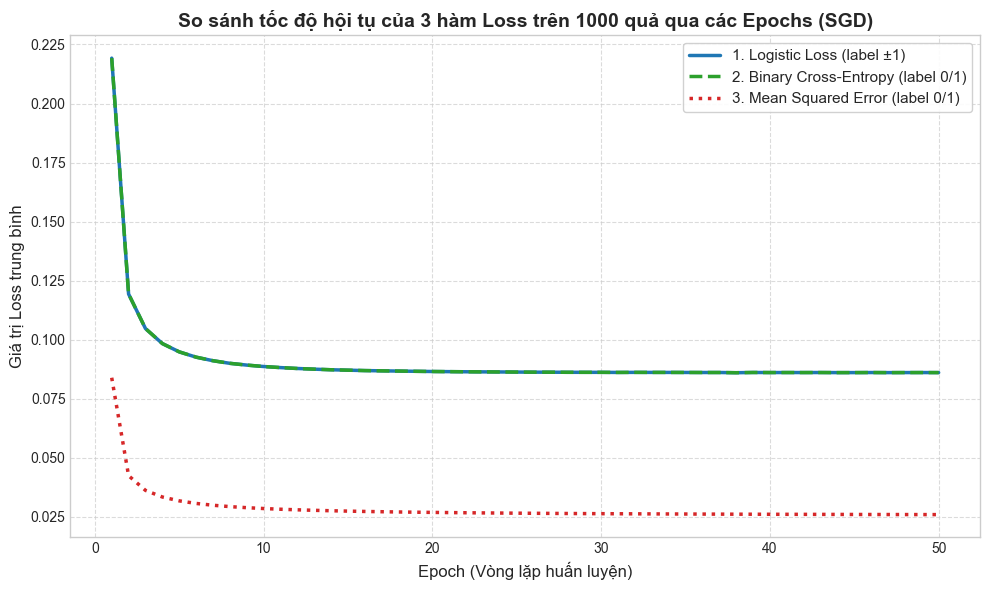

In [8]:
# BIỂU ĐỒ 1: SO SÁNH ĐƯỜNG CONG HÀM MẤT MÁT (LOSS CURVES)
plt.figure(figsize=(10, 6))

epochs_arr = np.arange(1, EPOCHS + 1)
plt.plot(epochs_arr, hist_log, label='1. Logistic Loss (label ±1)', color='#1f77b4', linewidth=2.5)
plt.plot(epochs_arr, hist_bce, label='2. Binary Cross-Entropy (label 0/1)', color='#2ca02c', linewidth=2.5, linestyle='--')
plt.plot(epochs_arr, hist_mse, label='3. Mean Squared Error (label 0/1)', color='#d62728', linewidth=2.5, linestyle=':')

plt.title('So sánh tốc độ hội tụ của 3 hàm Loss trên 1000 quả qua các Epochs (SGD)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Vòng lặp huấn luyện)', fontsize=12)
plt.ylabel('Giá trị Loss trung bình', fontsize=12)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


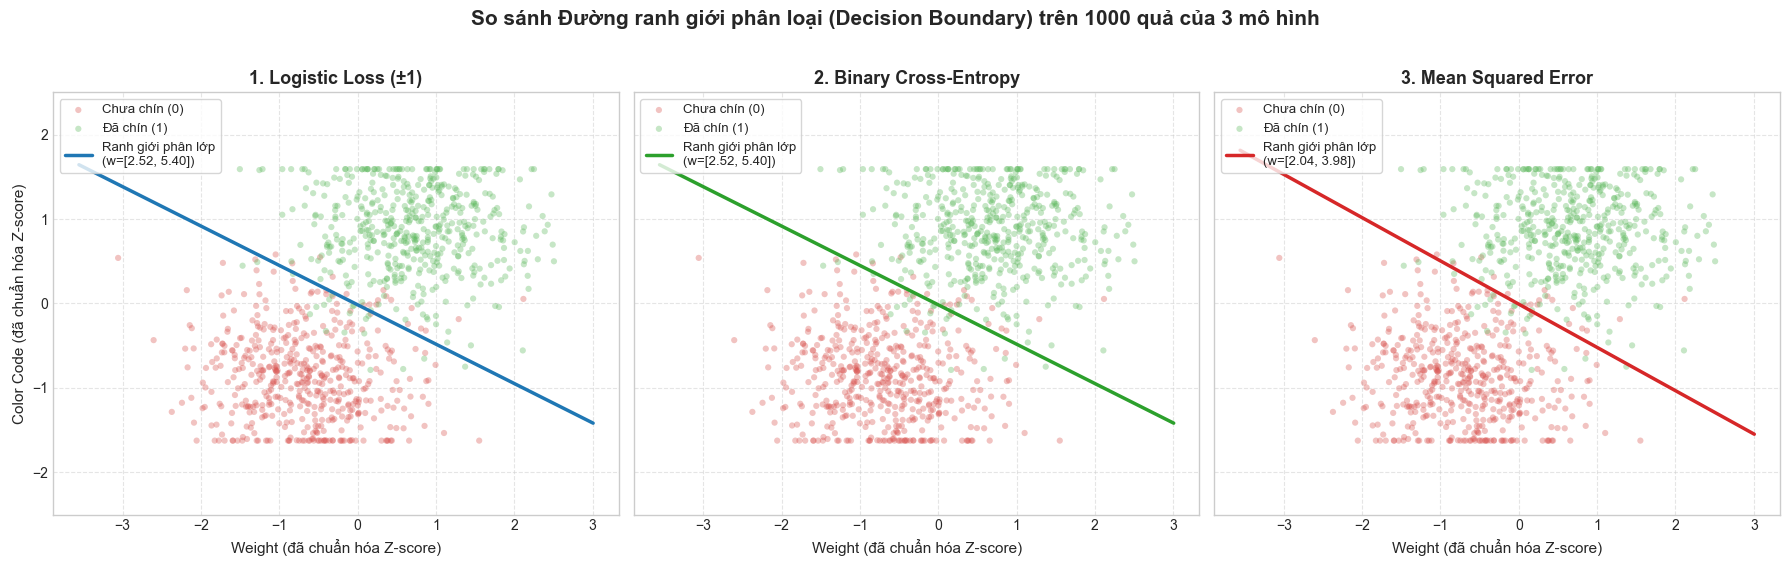

In [9]:
# BIỂU ĐỒ 2: SO SÁNH ĐƯỜNG RANH GIỚI PHÂN LỚP (DECISION BOUNDARIES) TRÊN 1000 MẪU
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

models = [
    ('1. Logistic Loss (±1)', w_log, b_log, '#1f77b4'),
    ('2. Binary Cross-Entropy', w_bce, b_bce, '#2ca02c'),
    ('3. Mean Squared Error', w_mse, b_mse, '#d62728')
]

# Tạo lưới giá trị x1 (Weight chuẩn hóa) để vẽ đường ranh giới w1*x1 + w2*x2 + b = 0
x1_vals_norm = np.linspace(X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5, 100)

for idx, (title, w, b, color) in enumerate(models):
    ax = axes[idx]
    
    # Vẽ 1000 điểm dữ liệu gốc (chuẩn hóa)
    ax.scatter(X_norm[y_01 == 0, 0], X_norm[y_01 == 0, 1],
               color='#d9534f', label='Chưa chín (0)', alpha=0.35, s=20, edgecolors='none')
    ax.scatter(X_norm[y_01 == 1, 0], X_norm[y_01 == 1, 1],
               color='#5cb85c', label='Đã chín (1)', alpha=0.35, s=20, edgecolors='none')
    
    # Phương trình đường phân chia: w1*x1 + w2*x2 + b = 0 => x2 = - (w1*x1 + b) / w2
    if abs(w[1]) > 1e-6:
        x2_vals_norm = - (w[0] * x1_vals_norm + b) / w[1]
        ax.plot(x1_vals_norm, x2_vals_norm, color=color, linewidth=2.5,
                label=f'Ranh giới phân lớp\n(w=[{w[0]:.2f}, {w[1]:.2f}])')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Weight (đã chuẩn hóa Z-score)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Color Code (đã chuẩn hóa Z-score)', fontsize=11)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(loc='upper left', fontsize=9.5, frameon=True, facecolor='white')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So sánh Đường ranh giới phân loại (Decision Boundary) trên 1000 quả của 3 mô hình', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [10]:
# BIỂU ĐỒ 3: BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG TRÊN 1000 MẪU
summary_df = pd.DataFrame([
    {
        'Mô hình Loss': '1. Logistic Loss (±1)',
        'Accuracy (%)': f"{metrics_log['Accuracy']*100:.2f}%",
        'Precision (%)': f"{metrics_log['Precision']*100:.2f}%",
        'Recall (%)': f"{metrics_log['Recall']*100:.2f}%",
        'F1-Score (%)': f"{metrics_log['F1_Score']*100:.2f}%",
        'Loss ban đầu': f"{hist_log[0]:.4f}",
        'Loss hội tụ': f"{hist_log[-1]:.4f}"
    },
    {
        'Mô hình Loss': '2. Binary Cross-Entropy',
        'Accuracy (%)': f"{metrics_bce['Accuracy']*100:.2f}%",
        'Precision (%)': f"{metrics_bce['Precision']*100:.2f}%",
        'Recall (%)': f"{metrics_bce['Recall']*100:.2f}%",
        'F1-Score (%)': f"{metrics_bce['F1_Score']*100:.2f}%",
        'Loss ban đầu': f"{hist_bce[0]:.4f}",
        'Loss hội tụ': f"{hist_bce[-1]:.4f}"
    },
    {
        'Mô hình Loss': '3. Mean Squared Error',
        'Accuracy (%)': f"{metrics_mse['Accuracy']*100:.2f}%",
        'Precision (%)': f"{metrics_mse['Precision']*100:.2f}%",
        'Recall (%)': f"{metrics_mse['Recall']*100:.2f}%",
        'F1-Score (%)': f"{metrics_mse['F1_Score']*100:.2f}%",
        'Loss ban đầu': f"{hist_mse[0]:.4f}",
        'Loss hội tụ': f"{hist_mse[-1]:.4f}"
    }
])

print("=== BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG 3 HÀM LOSS FUNCTION (1000 QUẢ) ===")
print(summary_df.to_string(index=False))


=== BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG 3 HÀM LOSS FUNCTION (1000 QUẢ) ===
           Mô hình Loss Accuracy (%) Precision (%) Recall (%) F1-Score (%) Loss ban đầu Loss hội tụ
  1. Logistic Loss (±1)       96.20%        96.39%     96.00%       96.19%       0.2192      0.0861
2. Binary Cross-Entropy       96.20%        96.39%     96.00%       96.19%       0.2192      0.0861
  3. Mean Squared Error       96.20%        96.39%     96.00%       96.19%       0.0839      0.0260


---
# PHẦN 6: KẾT LUẬN & CÂU HỎI ÔN TẬP VẤN ĐÁP (CHUẨN BỊ 40% ĐIỂM)

## 6.1. Nhận xét và đánh giá chuyên sâu
1. **Sự tương đồng giữa Logistic Loss và Binary Cross-Entropy (BCE):**
   * Về bản chất lý thuyết xác suất, cả hai đều xuất phát từ nguyên lý ước lượng hợp lý cực đại (*Maximum Likelihood Estimation - MLE*).
   * Điểm khác biệt duy nhất là cách mã hóa nhãn: Logistic loss dùng $\{-1, +1\}$ còn BCE dùng $\{0, 1\}$.
   * Kết quả thực nghiệm trên tập dữ liệu lớn 1000 quả cho thấy đường cong hội tụ, độ chính xác (Accuracy đạt ~ 96.20%) và đường biên phân loại của 2 mô hình này gần như trùng khớp hoàn toàn, hội tụ rất mượt mà và ổn định.

2. **Tại sao MSE bị hạn chế trong bài toán Phân loại (Classification)?**
   * **Vấn đề triệt tiêu Gradient (*Vanishing Gradient*):** Trong MSE, gradient có dạng $\nabla_{\mathbf{w}} = -2(y_i - p_i) \cdot p_i(1 - p_i) \mathbf{x}_i$. Khi một mẫu bị dự đoán rất sai (ví dụ nhãn $y=1$ nhưng mô hình dự đoán xác suất $p=0.01$), thành phần $p(1-p) = 0.01 \times 0.99 \approx 0.0099$ làm cho gradient bị triệt tiêu về gần 0. Mô hình "tưởng rằng không cần học nữa" dù sai số rất lớn!
   * **Tính phi lồi (*Non-convexity*):** Khi kết hợp hàm bình phương MSE với hàm phi tuyến Sigmoid, bề mặt mất mát không còn dạng hình chiếc bát lồi duy nhất, mà xuất hiện các vùng bằng phẳng (*plateau*) và điểm cực tiểu cục bộ, khiến thuật toán SGD dễ bị mắc kẹt.
   * Ngược lại, ở BCE, thành phần $p_i(1 - p_i)$ của Sigmoid đã bị triệt tiêu với mẫu số của đạo hàm hàm logarit, làm gradient tỉ lệ trực tiếp với sai số $(p_i - y_i)$. Sai số càng lớn thì gradient càng mạnh, giúp mô hình tự điều chỉnh cực nhanh.

---
## 6.2. Các câu hỏi phỏng vấn/vấn đáp giảng viên thường hỏi và câu trả lời gợi ý

> **❓ Câu hỏi 1: Tại sao phải dùng hàm Sigmoid trong Logistic Regression mà không dùng trực tiếp hàm tuyến tính?**
> * **Trả lời:** Hàm tuyến tính $z = \mathbf{w}^T \mathbf{x} + b$ có miền giá trị từ $-\infty$ đến $+\infty$, không phù hợp để biểu diễn xác suất. Hàm Sigmoid ánh xạ toàn bộ miền giá trị thực về khoảng $(0, 1)$, cho phép diễn giải đầu ra như một xác suất điều kiện $P(y=1|x)$, đồng thời có tính chất vi phân liên tục rất đẹp $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.

> **❓ Câu hỏi 2: Sự khác nhau cơ bản giữa Gradient Descent (GD), Stochastic Gradient Descent (SGD) và Mini-batch GD là gì?**
> * **Trả lời:**
>   * *Batch GD:* Tính gradient trên **toàn bộ** tập dữ liệu rồi mới cập nhật trọng số 1 lần $\rightarrow$ chậm nếu dữ liệu lớn.
>   * *SGD (đề bài yêu cầu):* Cập nhật trọng số ngay sau **từng mẫu đơn lẻ** $(x_i, y_i) \rightarrow$ tốc độ nhanh, có tính ngẫu nhiên giúp thoát khỏi cực tiểu cục bộ, nhưng đường đi loss dao động rung lắc.
>   * *Mini-batch GD:* Cập nhật theo từng nhóm nhỏ mẫu (ví dụ 16, 32, 64 mẫu) $\rightarrow$ kết hợp ưu điểm của cả hai phương pháp.

> **❓ Câu hỏi 3: Tại sao cần chuẩn hóa dữ liệu Z-score trước khi huấn luyện SGD?**
> * **Trả lời:** Các đặc trưng thường có đơn vị và thang đo khác nhau (ví dụ cân nặng hàng trăm gram, mã màu chỉ từ 0 đến 2). Nếu không chuẩn hóa, hàm loss sẽ có dạng elip rất hẹp, gradient sẽ dao động mạnh sang hai bên thành hẻm và tiến rất chậm về đáy. Chuẩn hóa giúp hàm loss có dạng đối xứng hình tròn, SGD đi thẳng và hội tụ nhanh hơn gấp nhiều lần.

> **❓ Câu hỏi 4: Chứng minh tại sao gradient của BCE lại không còn đạo hàm của Sigmoid?**
> * **Trả lời:** Đạo hàm của BCE theo $p$ là $\frac{\partial \mathcal{L}}{\partial p} = \frac{p - y}{p(1 - p)}$. Đạo hàm của Sigmoid theo $z$ là $\frac{\partial p}{\partial z} = p(1 - p)$. Áp dụng quy tắc chuỗi $\frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial p} \cdot \frac{\partial p}{\partial z} = \frac{p - y}{p(1 - p)} \cdot p(1 - p) = p - y$. Mẫu số $p(1 - p)$ triệt tiêu hoàn toàn với tử số.
